In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [3]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [4]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [5]:
X = data
y = data['SalePrice']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [8]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
276,NaN,TA,201000,TA,NaN
1457,Gd,TA,266500,TA,Gd
770,NaN,TA,134900,TA,NaN
808,Gd,TA,159950,TA,Gd
1069,NaN,TA,135000,TA,NaN


In [10]:
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual']
    .dropna()
    .sample(X_train['GarageQual_imputed'].isnull().sum(), random_state=42)
    .values
)

X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual']
    .dropna()
    .sample(X_test['GarageQual_imputed'].isnull().sum(), random_state=42)
    .values
)

In [11]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [13]:
temp

,original,imputed
TA,0.951043,0.952911
Fa,0.037171,0.035959
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [15]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(data)
        ],
        axis=1)

temp.columns = ['original', 'imputed']


In [16]:
temp

,original,imputed
Gd,0.494272,0.393151
TA,0.412439,0.330822
Fa,0.040917,0.034247
Po,0.027823,0.022603
Ex,0.024550,0.019178


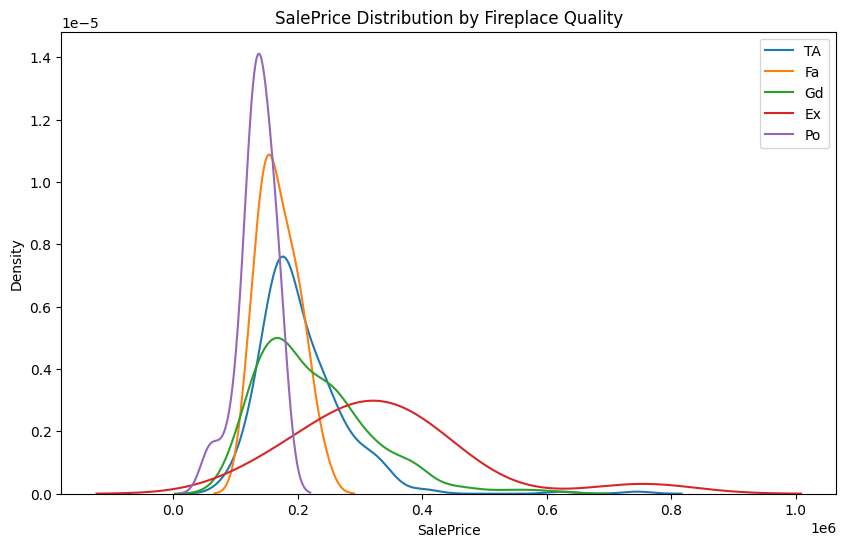

In [18]:
plt.figure(figsize=(10,6))

for category in X_train['FireplaceQu'].dropna().unique():
    data = X_train[X_train['FireplaceQu'] == category]['SalePrice']
    if len(data) > 0:
        sns.kdeplot(data, label=category)

plt.legend()
plt.title("SalePrice Distribution by Fireplace Quality")
plt.xlabel("SalePrice")
plt.ylabel("Density")
plt.show()

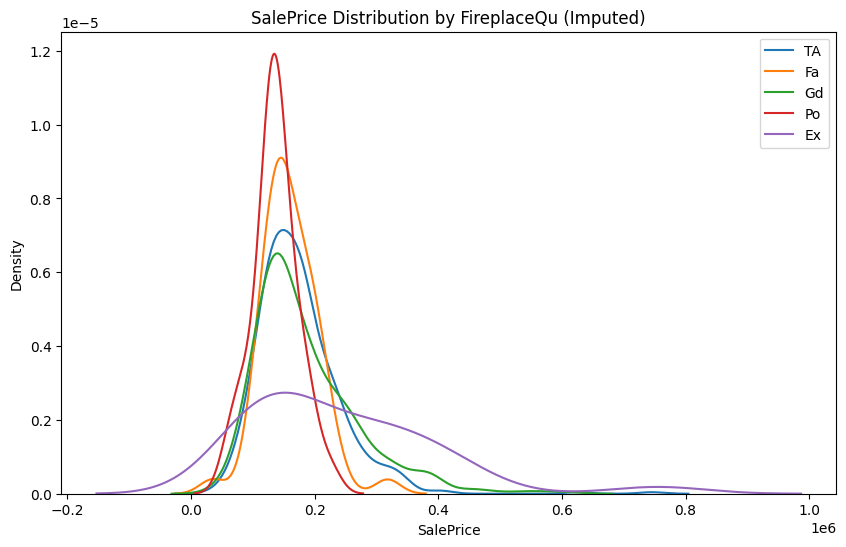

In [19]:
plt.figure(figsize=(10,6))

for category in X_train['FireplaceQu_imputed'].dropna().unique():
    data = X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice']
    
    if len(data) > 0:
        sns.kdeplot(data, label=category)

plt.legend()
plt.title("SalePrice Distribution by FireplaceQu (Imputed)")
plt.xlabel("SalePrice")
plt.ylabel("Density")
plt.show()